# 🍎 Apple Product Price Prediction

## Day 004 - 100 Days of Machine Learning

### 🎯 Objective

The objective of this project is to predict the selling price of Apple products using various product-related features such as platform, product category, model name, condition, ratings, reviews, and stock information.

This project demonstrates a complete machine learning regression workflow from data preprocessing to model evaluation.

# 📚 Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,root_mean_squared_error

import warnings
warnings.filterwarnings("ignore")

# 📂 Load Dataset

In [2]:
df = pd.read_csv('Data/apple_products_pricing_2020_2026.csv')

# 🔍 Dataset Overview

In [3]:
df.shape

(80000, 14)

In [4]:
df.columns

Index(['Date', 'Platform', 'Product_Category', 'Model_Name', 'Condition',
       'Launch_Price_USD', 'Launch_Price_INR', 'Current_Price_USD',
       'Current_Price_INR', 'Discount_Pct', 'Sale_Event', 'Stock_Status',
       'Rating', 'Reviews_Count'],
      dtype='str')

In [5]:
df.sample(5)

,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct,Sale_Event,Stock_Status,Rating,Reviews_Count
69978,2026-03-15,Flipkart,iPhone,iPhone 17 128GB,New,849,83202,836.27,82217.99,1.5,NaN,In Stock,4.4,737
14317,2023-05-06,Amazon,Mac,MacBook Air M2 256GB,New,1199,117502,1190.09,117025.82,0.7,NaN,In Stock,4.5,549
57081,2025-09-16,Flipkart,Mac,MacBook Pro 14-inch M3 Pro 512GB,New,1999,195902,1868.85,185607.24,6.5,NaN,In Stock,4.9,3696
15831,2023-06-28,Amazon,Watch,Apple Watch Series 7 (45mm),Renewed/Refurbished,429,42042,277.90,23608.81,35.2,NaN,In Stock,4.1,2613
46095,2025-03-27,Amazon,Mac,MacBook Pro 14-inch M3 Pro 512GB,Renewed/Refurbished,1999,195902,1525.72,130669.76,23.7,NaN,In Stock,3.9,2011


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               80000 non-null  str    
 1   Platform           80000 non-null  str    
 2   Product_Category   80000 non-null  str    
 3   Model_Name         80000 non-null  str    
 4   Condition          80000 non-null  str    
 5   Launch_Price_USD   80000 non-null  int64  
 6   Launch_Price_INR   80000 non-null  int64  
 7   Current_Price_USD  80000 non-null  float64
 8   Current_Price_INR  80000 non-null  float64
 9   Discount_Pct       80000 non-null  float64
 10  Sale_Event         6649 non-null   str    
 11  Stock_Status       80000 non-null  str    
 12  Rating             80000 non-null  float64
 13  Reviews_Count      80000 non-null  int64  
dtypes: float64(4), int64(3), str(7)
memory usage: 8.5 MB


In [7]:
df.isnull().sum()

Date                     0
Platform                 0
Product_Category         0
Model_Name               0
Condition                0
Launch_Price_USD         0
Launch_Price_INR         0
Current_Price_USD        0
Current_Price_INR        0
Discount_Pct             0
Sale_Event           73351
Stock_Status             0
Rating                   0
Reviews_Count            0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct,Rating,Reviews_Count
count,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000
mean,963.959125,94467.994250,782.769855,74628.342439,21.418826,4.450099,2405.995925
std,470.086413,46068.468464,461.673970,45117.872172,16.697310,0.269782,1973.630852
min,329.000000,32242.000000,109.930000,9157.680000,-2.000000,3.800000,10.000000
25%,599.000000,58702.000000,432.930000,41686.835000,6.700000,4.300000,896.000000
50%,799.000000,78302.000000,699.740000,67324.020000,21.300000,4.400000,1893.500000
75%,1199.000000,117502.000000,989.112500,96568.117500,36.800000,4.700000,3383.000000
max,1999.000000,195902.000000,2038.970000,203668.710000,73.100000,4.900000,11526.000000


# 📊 Exploratory Data Analysis (EDA) &  # 🧹 Data Cleaning  


In [10]:
df[df["Discount_Pct"] < 0][[
    "Model_Name",
    "Launch_Price_USD",
    "Current_Price_USD",
    "Discount_Pct"
]]

,Model_Name,Launch_Price_USD,Current_Price_USD,Discount_Pct
0,Apple Watch Series 6 (44mm),429,435.81,-1.6
1,Apple Watch Series 6 (44mm),429,436.49,-1.7
4,Apple Watch Series 6 (44mm),429,436.22,-1.7
5,Apple Watch Series 6 (44mm),429,436.29,-1.7
6,Apple Watch Series 6 (44mm),429,433.06,-0.9
...,...,...,...,...
79840,iPhone 17 128GB,849,858.05,-1.1
79924,iPhone 17 128GB,849,858.18,-1.1
79927,iPhone 17 128GB,849,853.01,-0.5
79993,iPhone 17 128GB,849,853.13,-0.5


In [11]:
df[df.select_dtypes(["object"]).columns].describe(include="all")

,Date,Platform,Product_Category,Model_Name,Condition,Sale_Event,Stock_Status
count,80000,80000,80000,80000,80000,6649,80000
unique,2130,2,4,31,2,4,3
top,2025-06-11,Flipkart,iPhone,iPhone 14 Pro 128GB,New,Black Friday,In Stock
freq,95,40043,28589,2734,59985,2497,55034


In [12]:
df['Sale_Event']=df['Sale_Event'].fillna('Normal')

<Axes: xlabel='Current_Price_USD', ylabel='Count'>

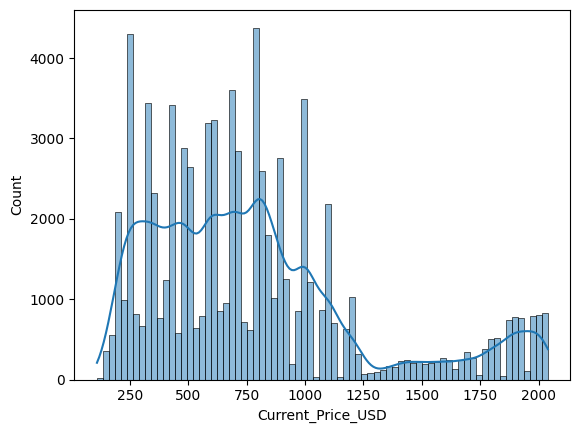

In [13]:
sns.histplot(df["Current_Price_USD"], kde=True)

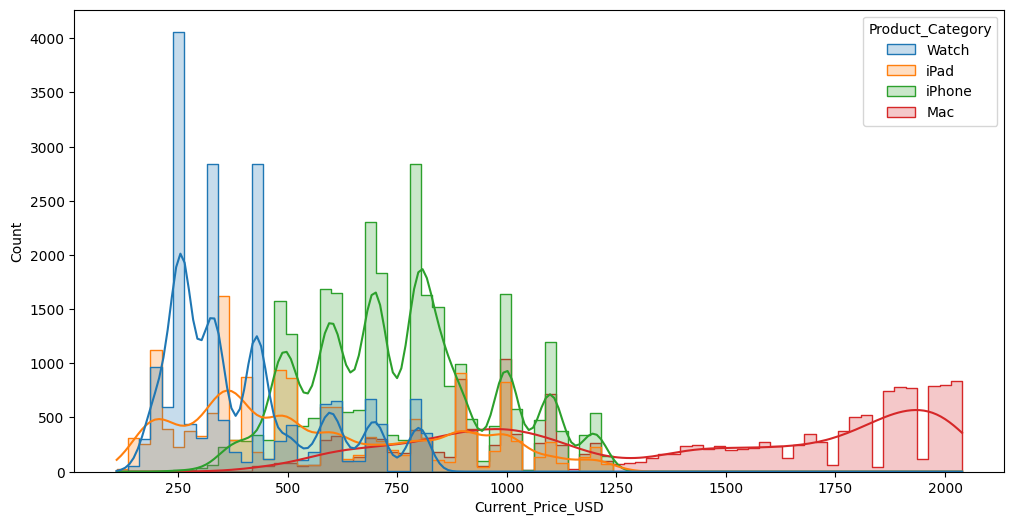

In [14]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x="Current_Price_USD",
    hue="Product_Category",
    kde=True,
    element="step"
)

plt.show()

<Axes: >

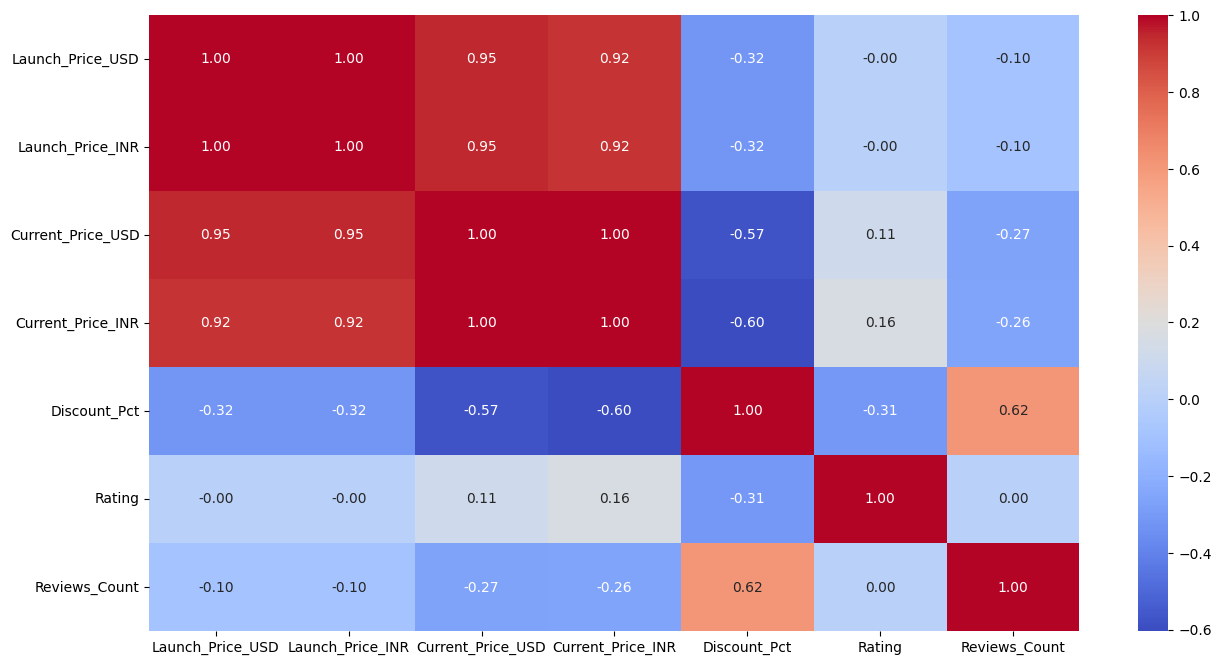

In [15]:
num_values= df.select_dtypes(include='number')
corr_matrix=num_values.corr()
plt.figure(figsize=(15,8))
sns.heatmap(corr_matrix,annot=True,fmt='.2f',cmap='coolwarm')

In [16]:
df.drop(['Launch_Price_INR','Current_Price_INR'],axis=1, inplace=True)

In [17]:
df.drop(['Discount_Pct'],axis=1, inplace=True)

In [18]:
for col in ["Platform", "Product_Category", "Condition",
            "Sale_Event", "Stock_Status"]:
    print(f"\n{col}")
    print(df.groupby(col)["Current_Price_USD"].mean().sort_values())


Platform
Platform
Flipkart    781.574259
Amazon      783.968025
Name: Current_Price_USD, dtype: float64

Product_Category
Product_Category
Watch      398.638561
iPad       573.083382
iPhone     758.674718
Mac       1382.489812
Name: Current_Price_USD, dtype: float64

Condition
Condition
Renewed/Refurbished    641.023114
New                    830.066030
Name: Current_Price_USD, dtype: float64

Sale_Event
Sale_Event
Big Billion Days         596.316827
Great Indian Festival    644.102926
Prime Day                664.368728
Black Friday             685.285991
Normal                   794.670885
Name: Current_Price_USD, dtype: float64

Stock_Status
Stock_Status
Out of Stock    694.365889
Low Stock       708.515858
In Stock        819.919547
Name: Current_Price_USD, dtype: float64


In [19]:
df.groupby(
    ["Sale_Event","Product_Category"]
)["Current_Price_USD"].mean()

Sale_Event             Product_Category
Big Billion Days       Mac                 1138.272465
                       Watch                324.677480
                       iPad                 481.707095
                       iPhone               569.623738
Black Friday           Mac                 1219.256750
                       Watch                342.761124
                       iPad                 501.846301
                       iPhone               662.621869
Great Indian Festival  Mac                 1162.794886
                       Watch                350.999465
                       iPad                 502.251324
                       iPhone               618.021315
Normal                 Mac                 1400.328833
                       Watch                404.147509
                       iPad                 579.708180
                       iPhone               771.133342
Prime Day              Mac                 1126.976015
                       Wa

In [20]:
df.groupby(
    ["Condition", "Product_Category"]
)["Current_Price_USD"].mean()

Condition            Product_Category
New                  Mac                 1465.623430
                     Watch                422.871341
                     iPad                 608.530127
                     iPhone               802.874899
Renewed/Refurbished  Mac                 1134.119161
                     Watch                327.807967
                     iPad                 467.596410
                     iPhone               623.304203
Name: Current_Price_USD, dtype: float64

# ⚙️ Feature Engineering

In [21]:
df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Quarter"] = df["Date"].dt.quarter

In [22]:
df.drop("Date", axis=1, inplace=True)

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Platform           80000 non-null  str    
 1   Product_Category   80000 non-null  str    
 2   Model_Name         80000 non-null  str    
 3   Condition          80000 non-null  str    
 4   Launch_Price_USD   80000 non-null  int64  
 5   Current_Price_USD  80000 non-null  float64
 6   Sale_Event         80000 non-null  str    
 7   Stock_Status       80000 non-null  str    
 8   Rating             80000 non-null  float64
 9   Reviews_Count      80000 non-null  int64  
 10  Year               80000 non-null  int32  
 11  Month              80000 non-null  int32  
 12  Quarter            80000 non-null  int32  
dtypes: float64(2), int32(3), int64(2), str(6)
memory usage: 7.0 MB


In [24]:
df["Model_Name"].nunique()

31

In [25]:
cat_cols = [
    "Platform",
    "Product_Category",
    "Model_Name",
    "Condition",
    "Sale_Event",
    "Stock_Status"
]
num_cols = [
    "Launch_Price_USD",
    "Rating",
    "Reviews_Count",
    "Year",
    "Month",
    "Quarter"
]

# 🎯 Feature Selection

In [26]:
X = df.drop("Current_Price_USD", axis=1)
y = df["Current_Price_USD"]

# ✂️ Train-Test Split

In [27]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

# 🔄 Feature Encoding

In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore",drop='first'),
            cat_cols
        )
    ],
    remainder="passthrough"
)


In [29]:
X_train = preprocessor.fit_transform(X_train)

In [30]:
X_test = preprocessor.transform(X_test)

# 🤖 Model Training

In [31]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

scores = cross_val_score(
    lr,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print(scores.mean())

0.978471458333034


In [32]:
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

R²: 0.9783774782999858
MAE: 49.9389893510419
RMSE: 68.01213681875069


In [33]:
train_pred = lr.predict(X_train)

print("Train R²:", r2_score(y_train, train_pred))
print("Test R² :", r2_score(y_test, y_pred))

Train R²: 0.9785132048724108
Test R² : 0.9783774782999858


In [34]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print(scores)
print(scores.mean())

[0.99529875 0.99536374 0.99521798 0.99516268 0.99539205]
0.9952870387467521


In [35]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [36]:
y_pred = rf.predict(X_test)

print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

R²: 0.9953632785774195
MAE: 19.251840185697755
RMSE: 31.494792469914344


In [37]:
train_pred = rf.predict(X_train)

print("Train R²:", r2_score(y_train, train_pred))
print("Test R² :", r2_score(y_test, y_pred))

Train R²: 0.9993546227520164
Test R² : 0.9953632785774195


In [38]:
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score

xgb = XGBRegressor(
    random_state=42,
    n_estimators=100,
    objective="reg:squarederror",
    n_jobs=-1
)

scores = cross_val_score(
    xgb,
    X_train,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print(scores)
print(scores.mean())

[0.99602405 0.99576308 0.99578607 0.99574472 0.99585974]
0.9958355331025267


In [39]:
xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)

In [40]:
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

R²: 0.9958863928560894
MAE: 19.658562235094703
RMSE: 29.665020702288167


In [41]:
train_pred = xgb.predict(X_train)

print("Train R²:", r2_score(y_train, train_pred))
print("Test R² :", r2_score(y_test, y_pred))

Train R²: 0.9967572005775213
Test R² : 0.9958863928560894


# ✅ Conclusion

This project implemented a complete machine learning regression pipeline to predict Apple product prices. Three regression models were trained and evaluated using R² Score, Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE).

## 📊 Model Performance Summary

| Model | R² Score | MAE | RMSE |
|:---------------------------|---------:|---------:|---------:|
| Linear Regression | **0.9784** | **49.94** | **68.01** |
| Random Forest Regressor | **0.9954** | **19.25** | **31.49** |
| XGBoost Regressor | **0.9959** | **19.66** | **29.67** |

---

## 🏆 Best Performing Model

**🥇 XGBoost Regressor**

### Performance

- **R² Score:** 0.9959
- **MAE:** 19.66
- **RMSE:** 29.67

### Why it performed the best?

- Achieved the **highest R² Score**, explaining approximately **99.59%** of the variance in the target variable.
- Produced the **lowest RMSE**, indicating the most accurate overall predictions.
- Demonstrated excellent generalization compared to the other regression models.